<a href="https://colab.research.google.com/github/ushayenumula01-wq/project-1/blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
df = pd.read_csv("train.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())   #Handle Missing values

In [11]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [12]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [15]:
df = df.drop_duplicates()
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

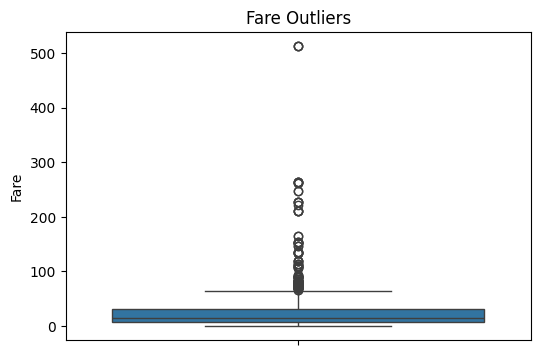

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df["Fare"])          #Identify Outliers
plt.title("Fare Outliers")
plt.show()

In [17]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]
df.shape

(775, 12)

In [20]:
female = df[df["Sex"] == "female"]       #Age Greater than 18
female.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Unknown,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,Unknown,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S


In [21]:
first = df[df["Pclass"] == 1]     #First class passangers
first.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,A6,S
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,Unknown,C


In [22]:
female_first = df[(df["Sex"]=="female") & (df["Pclass"]==1)] # Female passengers in First Class
female_first.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
136,137,1,1,"Newsom, Miss. Helen Monypeny",female,19.0,0,2,11752,26.2833,D47,S
166,167,1,1,"Chibnall, Mrs. (Edith Martha Bowerman)",female,28.0,0,1,113505,55.0000,E33,S
177,178,0,1,"Isham, Miss. Ann Elizabeth",female,50.0,0,0,PC 17595,28.7125,C49,C


In [23]:
df.sort_values("Fare", ascending=False).head()   #Sorting the data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
754,755,1,2,"Herman, Mrs. Samuel (Jane Laver)",female,48.0,1,2,220845,65.0000,Unknown,S
615,616,1,2,"Herman, Miss. Alice",female,24.0,1,2,220845,65.0000,Unknown,S
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,63.3583,D10 D12,C
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
155,156,0,1,"Williams, Mr. Charles Duane",male,51.0,0,1,PC 17597,61.3792,Unknown,C


In [24]:
df.groupby("Sex")["Fare"].mean()  #Grouping the data

,Fare
Sex,
female,20.506559
male,16.588550


In [25]:
df["Survived"].value_counts()

,count
Survived,
0,512
1,263


In [27]:
df.groupby("Sex")["Survived"].mean() # Survival by Gender

,Survived
Sex,
female,0.688525
male,0.178908


In [28]:
df.groupby("Pclass")["Survived"].mean()  # Survival by Passenger Class


,Survived
Pclass,
1,0.508929
2,0.486034
3,0.245868


In [29]:
df["Age"].mean()  # Average Age

np.float64(28.748709677419356)

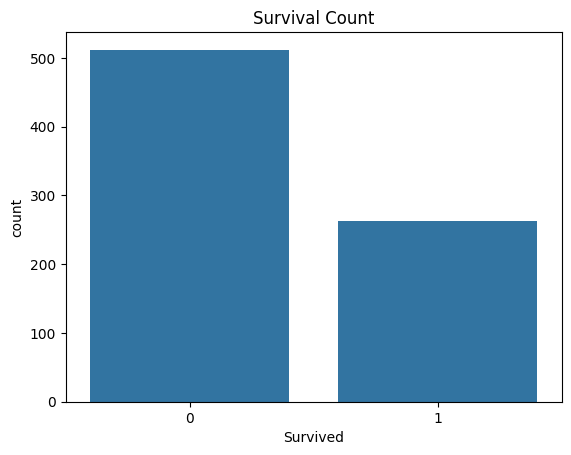

In [31]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")       #Survival Count
plt.show()

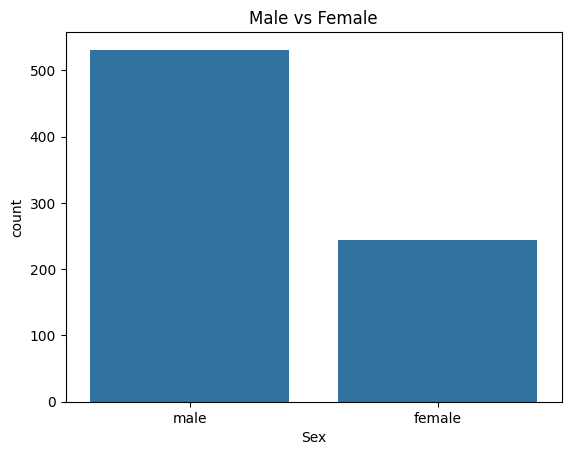

In [32]:
sns.countplot(x="Sex", data=df)
plt.title("Male vs Female")        #Gender Count
plt.show()

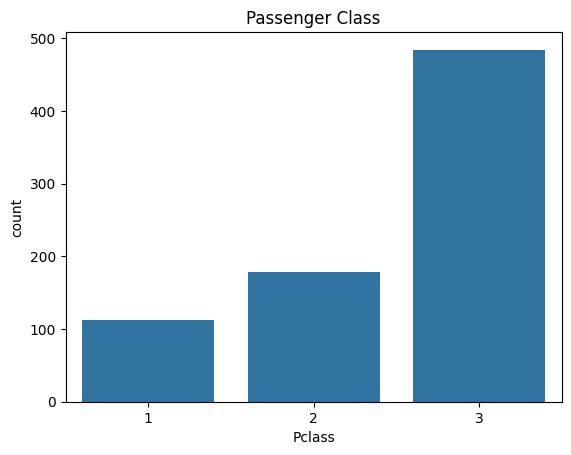

In [33]:
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class")      #Passenger Class
plt.show()

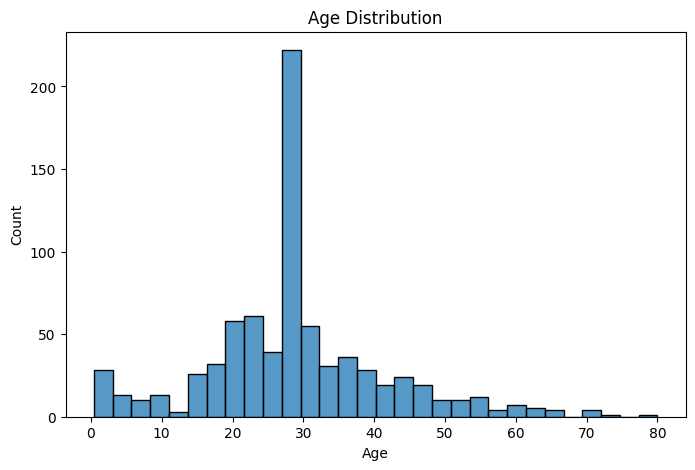

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30)
plt.title("Age Distribution")             #Age Distribution
plt.show()

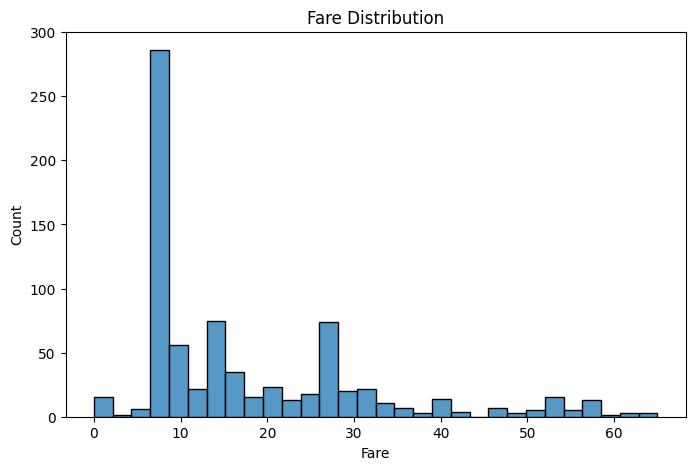

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["Fare"], bins=30)     #Fare Distribution
plt.title("Fare Distribution")
plt.show()

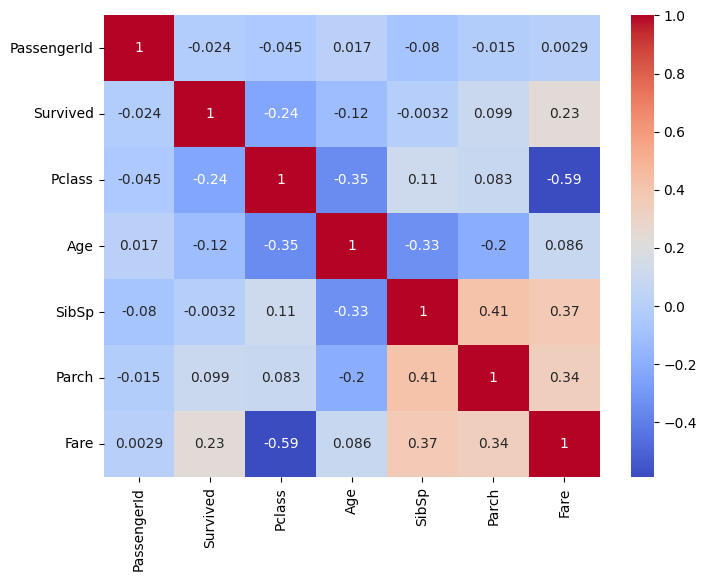

In [36]:
numeric = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))         #Correlation Heatmap
sns.heatmap(numeric.corr(),annot= True, cmap="coolwarm")
plt.show()

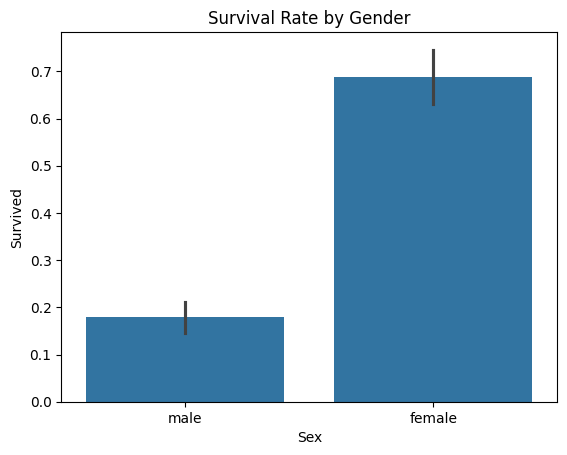

In [37]:
sns.barplot(x="Sex", y="Survived", data=df)
plt.title("Survival Rate by Gender")       #Survival by gender
plt.show()

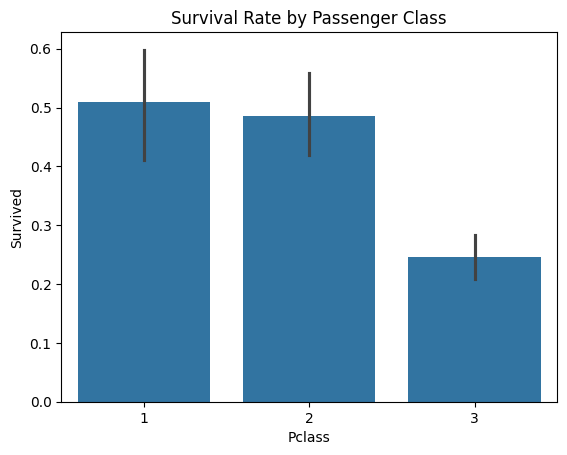

In [40]:
sns.barplot(x="Pclass", y="Survived", data=df)
plt.title("Survival Rate by Passenger Class")    #Survival by Passenger Class
plt.show()

 EDA Report

**Objective:**
To clean the Titanic dataset and analyze passenger survival.

**Data Cleaning:**

* Loaded the dataset.
* Filled missing values.
* Removed duplicate records.
* Removed outliers.

**Data Analysis:**

* Filtered data by age, gender, and class.
* Grouped data using `groupby()`.
* Calculated survival statistics.

**Visualizations:**

* Survival Count
* Gender Count
* Passenger Class Count
* Age Distribution
* Fare Distribution
* Survival by Gender
* Survival by Passenger Class
